In [85]:
import cmocean.cm as cm
import copy
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.colors as mcolors
#
from Calculations_Functions import proportions_from_filename, metrics_table
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')

In [86]:
import Regions_functions_V2

In [87]:
points_x_N1, points_y_N1 = Regions_functions_V2.points_x_N1, Regions_functions_V2.points_y_N1 
points_x_N2, points_y_N2 = Regions_functions_V2.points_x_N2, Regions_functions_V2.points_y_N2
points_x_N3, points_y_N3 = Regions_functions_V2.points_x_N3, Regions_functions_V2.points_y_N3
points_x_C1, points_y_C1 = Regions_functions_V2.points_x_C1, Regions_functions_V2.points_y_C1
points_x_S1, points_y_S1 = Regions_functions_V2.points_x_S1, Regions_functions_V2.points_y_S1 
points_x_SP, points_y_SP = Regions_functions_V2.points_x_SP, Regions_functions_V2.points_y_SP 
points_x_S2, points_y_S2 = Regions_functions_V2.points_x_S2, Regions_functions_V2.points_y_S2
points_x_H1, points_y_H1 = Regions_functions_V2.points_x_H1, Regions_functions_V2.points_y_H1
points_x_J1, points_y_J1 = Regions_functions_V2.points_x_J1, Regions_functions_V2.points_y_J1
points_x_F1, points_y_F1 = Regions_functions_V2.points_x_F1, Regions_functions_V2.points_y_F1
points_x_HW1, points_y_HW1 = Regions_functions_V2.points_x_HW1, Regions_functions_V2.points_y_HW1

In [88]:
jjii = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [89]:
lon_cores = (-1) * np.array([124 + (38.282/60), 123 + (18.517/60), 123 + (17.991/60), 123 + (18.718/60), 123 + (32.731/60), 123 + (18.812/60), 123 + (22.162/60)])
lat_cores = np.array([49 + (35.515/60), 49 + (19.902/60), 49 + (12.467/60), 49 + (7.778/60), 49 + (9.877/60), 48 + (56.192/60), 49 + (3.340/60)])
cores_labels = ['GVRD-1', 'GVRD-2', 'GVRD-3', 'GVRD-4', 'GVRD-5', 'GVRD-6', 'GVRD-7']
#
stations = ['JF2', 'HS', 'S4-1.5', 'S2', 'NG', 'S1 (plume)', 'S3', 'FR']
lat = np.array([48 + (18/60), 48 + (37.80/60) , 49 + (15/60) , 49 + (17.58/60) , 49 + (43.60/60), 49 + (12.32/60), 49 + (17.88/60), 49 + (08.66/60)])
lon = (-1) * np.array([124, 123 + (14.60/60), 123 + (40/60), 123 + (22.51/60), 124 + (40.80/60), 123 + (18/60), 123 + (04.91/60), 123 + (02.65/60)]) 

In [90]:
x_obs_WC = np.zeros_like(lon, dtype=int)
y_obs_WC = np.zeros_like(lat, dtype=int)
for j in range(len(lon)):
    jj, ii = finder(lat[j], lon[j])
    x_obs_WC[j] = ii
    y_obs_WC[j] = jj
#
x_obs_S = np.zeros_like(lon_cores, dtype=int)
y_obs_S = np.zeros_like(lat_cores, dtype=int)
for j in range(len(lon_cores)):
    jj, ii = finder(lat_cores[j], lon_cores[j])
    x_obs_S[j] = ii
    y_obs_S[j] = jj

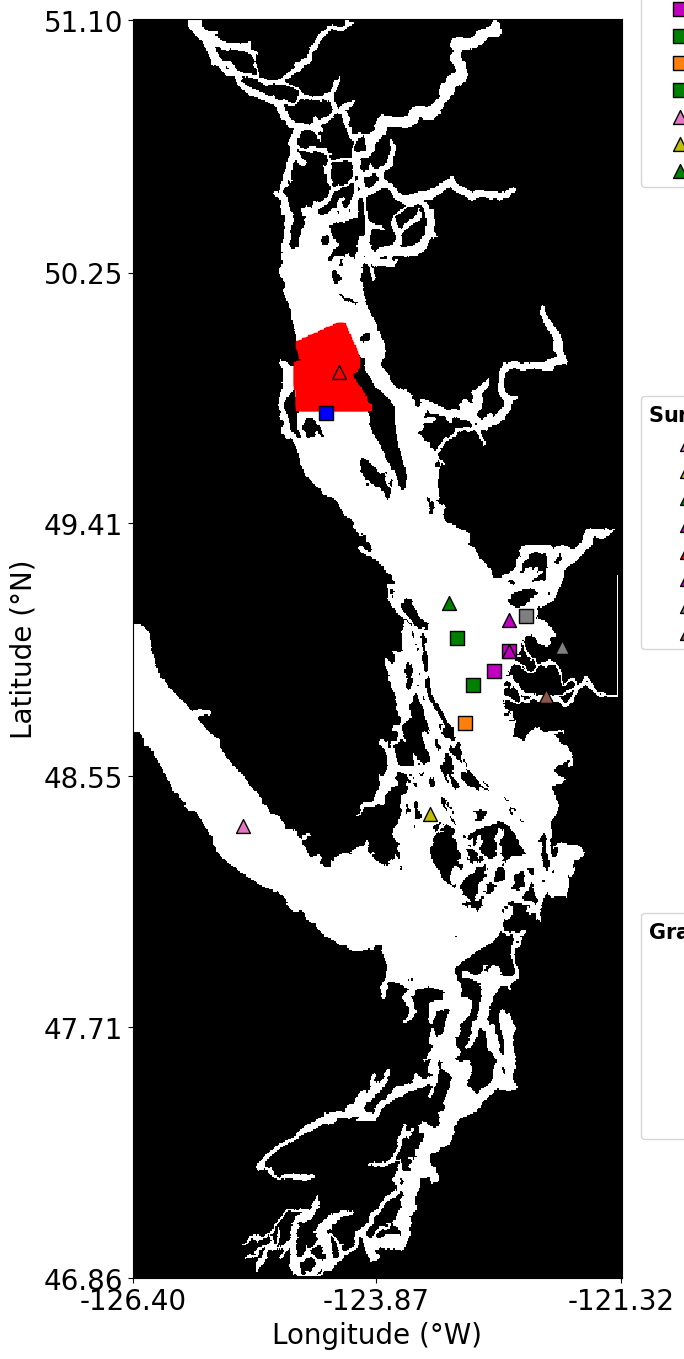

In [ ]:
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')
bathy = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc')

# --- Define colormap ---
colors = [(0, 0, 0, 1),  # Grey for land
          (0, 0, 0, 0)]        # Transparent for water
cmap = ListedColormap(colors)

plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(figsize=(12, 14))
# --- Create coordinate arrays for pcolormesh ---
LON = np.linspace(mask['nav_lon'].min().values,
                  mask['nav_lon'].max().values,
                  len(mask.x))
LAT = np.linspace(mask['nav_lat'].min().values,
                  mask['nav_lat'].max().values,
                  len(mask.y))
longitudes, latitudes = np.meshgrid(LON, LAT)

# --- Plot mask using lon/lat coordinates ---
pcm = ax.pcolormesh(mask['tmask'][0, 0],
                    cmap=cmap, shading='auto')

# --- Regions ---
colors_regions = ['r', 'b', 'tab:purple', 'c', 'g', 'm', 'tab:gray', 'tab:brown', 'tab:orange', 'y', 'tab:pink']
regions = ['NSoG (N1)', 'NSoG (N2)', 'NSoG (N3)', 'CSoG (C1)', 'SSoG (S1)',
           'I. Plume (SP)', 'Howe S. (HW1)', 'Fraser R. (F1)', 'SSoG (S2)', 'Haro S. (H1)', 'JdF S. (J1)']

ax.scatter(points_x_N1, points_y_N1, c=colors_regions[0], s=20, marker='s', label=regions[0])
ax.scatter(points_x_N2, points_y_N2, c=colors_regions[1], s=20, marker='s', label=regions[1])
ax.scatter(points_x_N3, points_y_N3, c=colors_regions[2], s=20, marker='s', label=regions[2])
ax.scatter(points_x_C1, points_y_C1, c=colors_regions[3], s=20, marker='s', label=regions[3])
ax.scatter(points_x_S1, points_y_S1, c=colors_regions[4], s=20, marker='s', label=regions[4])
ax.scatter(points_x_SP, points_y_SP, c=colors_regions[5], s=20, marker='s', label=regions[5])
ax.scatter(points_x_HW1, points_y_HW1, c=colors_regions[6], s=20, marker='s', label=regions[6])
ax.scatter(points_x_F1, points_y_F1, c=colors_regions[7], s=20, marker='s', label=regions[7])
ax.scatter(points_x_S2, points_y_S2, c=colors_regions[8], s=20, marker='s', label=regions[8])
ax.scatter(points_x_H1, points_y_H1, c=colors_regions[9], s=20, marker='s', label=regions[9])
ax.scatter(points_x_J1, points_y_J1, c=colors_regions[10], s=20, marker='s', label=regions[10])

# --- Cores ("Grant et al., 2011") ---
color_cores = ['b', 'tab:gray', 'm', 'm', 'g', 'tab:orange', 'g']
scatter_cores = []
for i in range(len(lon_cores)):
    s = ax.scatter(x_obs_S[i], y_obs_S[i], marker='s', edgecolors='k',
                   c=color_cores[i], label=cores_labels[i], s=100)
    scatter_cores.append(s)

# --- Stations ("Sun et al., 2023") ---
color_stations = ['tab:pink', 'y', 'g', 'm', 'r', 'm', 'tab:gray', 'tab:brown']
scatter_stations = []
for i in range(len(lon)):
    s = ax.scatter(x_obs_WC[i], y_obs_WC[i], marker='^', edgecolors='k',
                   c=color_stations[i], label=stations[i], s = 100)
    scatter_stations.append(s)

# --- Labels and aspect ---
ax.set_ylabel('Latitude')
ax.set_xlabel('Longitude')
ax.set_aspect(1.14)

# --- Set lon/lat ticks directly ---
# Compute lon/lat tick labels
LON = np.linspace(mask['nav_lon'].min().values,
                  mask['nav_lon'].max().values,
                  len(mask.x))
LAT = np.linspace(mask['nav_lat'].min().values,
                  mask['nav_lat'].max().values,
                  len(mask.y))

# Set tick positions and labels
n_xticks = 3
n_yticks = 6
xtick_positions = np.linspace(0, len(LON) - 1, n_xticks).astype(int)
ytick_positions = np.linspace(0, len(LAT) - 1, n_yticks).astype(int)

ax.set_xticks(xtick_positions)
ax.set_xticklabels([f"{LON[i]:.2f}" for i in xtick_positions])

ax.set_yticks(ytick_positions)
ax.set_yticklabels([f"{LAT[i]:.2f}" for i in ytick_positions])

ax.set_xlabel("Longitude (°W)")
ax.set_ylabel("Latitude (°N)")


# --- Legends outside the plot ---

# 1️⃣ Collect handles and labels for model regions
handles_regions, labels_regions = ax.get_legend_handles_labels()
region_handles = handles_regions[:len(regions)]  # first ones are the region scatters
region_labels = labels_regions[:len(regions)]

# 2️⃣ Create individual legends
legend_model = ax.legend(handles=region_handles, labels=region_labels,
                         title=r"$\bf{Model}$ $\bf{Regions}$", fontsize=13, title_fontsize=15, frameon=True,
                         loc = 'upper center', ncol = 2)

legend_sun = ax.legend(handles=scatter_stations, title=r"$\bf{Sun}$ $\bf{et}$ $\bf{al.,}$ $\bf{2023}$",
                       fontsize=13, title_fontsize=15, frameon=True, loc = 'lower left')

legend_grant = ax.legend(handles=scatter_cores, title=r"$\bf{Grant}$ $\bf{et}$ $\bf{al.,}$ $\bf{2011}$",
                         fontsize=13, title_fontsize=15, frameon=True, loc = 'lower right')

# 3️⃣ Add legends manually, stacked outside the plot
ax.add_artist(legend_model)
ax.add_artist(legend_sun)
ax.add_artist(legend_grant)

#
plt.tight_layout()
plt.show()


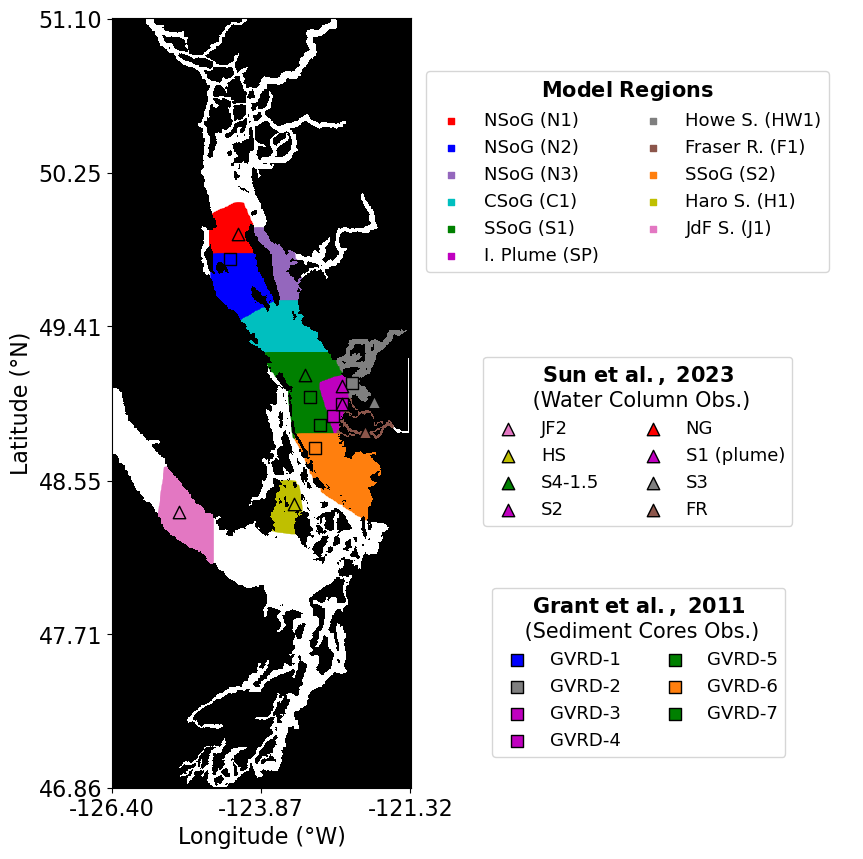

In [157]:
from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec
#
# --- Load data ---
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')
bathy = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc')

# --- Define colormap ---
colors = [(0, 0, 0, 1),  # Grey for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors)

plt.rcParams.update({'font.size': 16})
fig = plt.figure(figsize=(20,10)) 
gs = gridspec.GridSpec(1, 2, width_ratios=[2,1], figure=fig)

ax = fig.add_subplot(gs[0,0])   # top left
ax1 = fig.add_subplot(gs[0,1])   # bottom left
ax1.axis('off')
# --- Create coordinate arrays for pcolormesh ---
LON = np.linspace(mask['nav_lon'].min().values,
                  mask['nav_lon'].max().values,
                  len(mask.x))
LAT = np.linspace(mask['nav_lat'].min().values,
                  mask['nav_lat'].max().values,
                  len(mask.y))
longitudes, latitudes = np.meshgrid(LON, LAT)


# --- Regions ---
colors_regions = ['r', 'b', 'tab:purple', 'c', 'g', 'm', 'tab:gray', 'tab:brown', 'tab:orange', 'y', 'tab:pink']
regions = ['NSoG (N1)', 'NSoG (N2)', 'NSoG (N3)', 'CSoG (C1)', 'SSoG (S1)',
           'I. Plume (SP)', 'Howe S. (HW1)', 'Fraser R. (F1)', 'SSoG (S2)', 'Haro S. (H1)', 'JdF S. (J1)']
#
ax.scatter(points_x_N1, points_y_N1, c=colors_regions[0], s=20, marker='s', label=regions[0])
ax.scatter(points_x_N2, points_y_N2, c=colors_regions[1], s=20, marker='s', label=regions[1])
ax.scatter(points_x_N3, points_y_N3, c=colors_regions[2], s=20, marker='s', label=regions[2])
ax.scatter(points_x_C1, points_y_C1, c=colors_regions[3], s=20, marker='s', label=regions[3])
ax.scatter(points_x_S1, points_y_S1, c=colors_regions[4], s=20, marker='s', label=regions[4])
ax.scatter(points_x_SP, points_y_SP, c=colors_regions[5], s=20, marker='s', label=regions[5])
ax.scatter(points_x_HW1, points_y_HW1, c=colors_regions[6], s=20, marker='s', label=regions[6])
ax.scatter(points_x_F1, points_y_F1, c=colors_regions[7], s=20, marker='s', label=regions[7])
ax.scatter(points_x_S2, points_y_S2, c=colors_regions[8], s=20, marker='s', label=regions[8])
ax.scatter(points_x_H1, points_y_H1, c=colors_regions[9], s=20, marker='s', label=regions[9])
ax.scatter(points_x_J1, points_y_J1, c=colors_regions[10], s=20, marker='s', label=regions[10])
#
pcm = ax.pcolormesh(mask['tmask'][0, 0], cmap=cmap, shading='auto')

# --- Cores ("Grant et al., 2011") ---
color_cores = ['b', 'tab:gray', 'm', 'm', 'g', 'tab:orange', 'g']
scatter_cores = []
for i in range(len(lon_cores)):
    s = ax.scatter(x_obs_S[i], y_obs_S[i], marker='s', edgecolors='k',
                   c=color_cores[i], label=cores_labels[i], s=80)
    scatter_cores.append(s)

# --- Stations ("Sun et al., 2023") ---
color_stations = ['tab:pink', 'y', 'g', 'm', 'r', 'm', 'tab:gray', 'tab:brown']
scatter_stations = []
for i in range(len(lon)):
    s = ax.scatter(x_obs_WC[i], y_obs_WC[i], marker='^', edgecolors='k',
                   c=color_stations[i], label=stations[i], s=80)
    scatter_stations.append(s)

# --- Labels and aspect ---
ax.set_ylabel('Latitude')
ax.set_xlabel('Longitude')
ax.set_aspect(1.14)

# --- Set lon/lat ticks directly ---
n_xticks = 3
n_yticks = 6
xtick_positions = np.linspace(0, len(LON) - 1, n_xticks).astype(int)
ytick_positions = np.linspace(0, len(LAT) - 1, n_yticks).astype(int)

ax.set_xticks(xtick_positions)
ax.set_xticklabels([f"{LON[i]:.2f}" for i in xtick_positions])
ax.set_yticks(ytick_positions)
ax.set_yticklabels([f"{LAT[i]:.2f}" for i in ytick_positions])

ax.set_xlabel("Longitude (°W)")
ax.set_ylabel("Latitude (°N)")

# --- Legends stacked on the right ---
from matplotlib.legend import Legend

# 1️⃣ Model regions
handles_regions, labels_regions = ax.get_legend_handles_labels()
region_handles = handles_regions[:len(regions)]
region_labels = labels_regions[:len(regions)]
legend_model = Legend(ax, region_handles, region_labels, title=r"$\bf{Model}$ $\bf{Regions}$",
                      fontsize=13, title_fontsize=15, loc='center left', bbox_to_anchor=(1.02, .8), ncol = 2)

# 2️⃣ Sun et al. stations
legend_sun = Legend(ax, scatter_stations, stations, title=r"$\bf{Sun}$ $\bf{et}$ $\bf{al.,}$ $\bf{2023}$" + '\n (Water Column Obs.)',
                    fontsize=13, title_fontsize=15, loc='center left', bbox_to_anchor=(1.21, 0.45), ncol = 2)

# 3️⃣ Grant et al. cores
legend_grant = Legend(ax, scatter_cores, cores_labels, title=r"$\bf{Grant}$ $\bf{et}$ $\bf{al.,}$ $\bf{2011}$" + '\n (Sediment Cores Obs.)',
                      fontsize=13, title_fontsize=15, loc='center left', bbox_to_anchor=(1.24, 0.15), ncol = 2)

# Add all legends manually
legend_model.get_title().set_ha('center')
legend_sun.get_title().set_ha('center')
legend_grant.get_title().set_ha('center')

ax.add_artist(legend_model)
ax.add_artist(legend_sun)
ax.add_artist(legend_grant)

plt.subplots_adjust(right=0.55)  # leave 25% space on the right for legends
